# Блок 1: Импорт необходимых библиотек

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (accuracy_score, classification_report, 
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки импортированы")

Библиотеки импортированы


# Блок 2: Загрузка датасетов из локальной директории

In [26]:
try:
    gun_data = pd.read_csv('gun-violence-data.csv')
    anime_data = pd.read_csv('anime.csv')
    print("Датасеты успешно загружены")
    print(f"Gun Violence Data: {gun_data.shape}")
    print(f"Anime Data: {anime_data.shape}")
except FileNotFoundError as e:
    print(f"Ошибка загрузки файлов: {e}")
    print("Убедитесь, что файлы находятся в правильной директории")

Датасеты успешно загружены
Gun Violence Data: (239677, 29)
Anime Data: (12294, 7)


# Блок 3: Первичный анализ датасета Gun Violence (регрессия)

In [27]:
print(f"Исходный размер датасета: {gun_data.shape}")
print("\nВсе столбцы датасета:")
print(gun_data.columns.tolist())

print("\nПервые 2 строки:")
print(gun_data.head(2))

print("\nИнформация о данных:")
print(gun_data.info())

Исходный размер датасета: (239677, 29)

Все столбцы датасета:
['incident_id', 'date', 'state', 'city_or_county', 'address', 'n_killed', 'n_injured', 'incident_url', 'source_url', 'incident_url_fields_missing', 'congressional_district', 'gun_stolen', 'gun_type', 'incident_characteristics', 'latitude', 'location_description', 'longitude', 'n_guns_involved', 'notes', 'participant_age', 'participant_age_group', 'participant_gender', 'participant_name', 'participant_relationship', 'participant_status', 'participant_type', 'sources', 'state_house_district', 'state_senate_district']

Первые 2 строки:
   incident_id        date         state city_or_county  \
0       461105  2013-01-01  Pennsylvania     Mckeesport   
1       460726  2013-01-01    California      Hawthorne   

                                     address  n_killed  n_injured  \
0  1506 Versailles Avenue and Coursin Street         0          4   
1               13500 block of Cerise Avenue         1          3   

             

# Блок 4: Удаление неиспользуемых столбцов и подготовка данных для регрессии

Будет удалено 24 столбцов

Размер датасета после удаления столбцов: (239677, 6)
Оставшиеся столбцы: ['state', 'city_or_county', 'latitude', 'longitude', 'n_guns_involved', 'total_victims']

Удалено 107359 строк с пропущенными значениями
Размер очищенного датасета: (132318, 6)

Распределение целевой переменной 'total_victims':
count    132318.000000
mean          0.693708
std           0.877481
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max         103.000000
Name: total_victims, dtype: float64


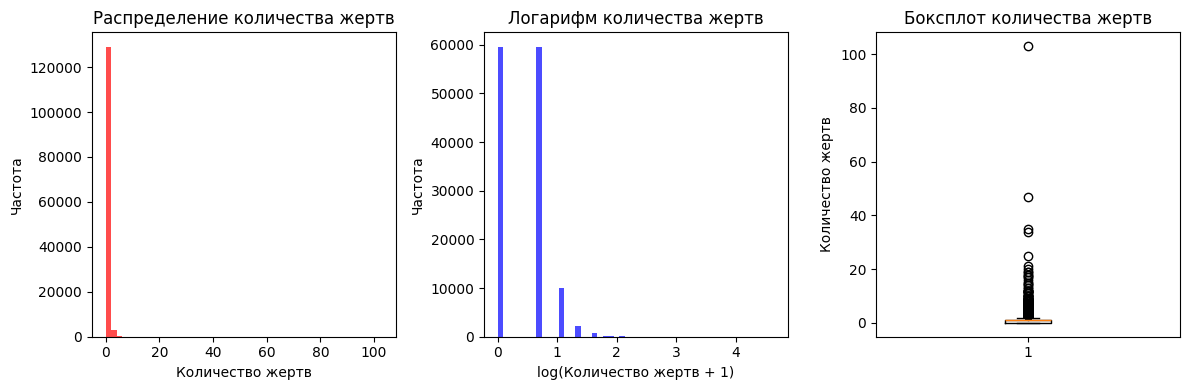

In [28]:
# Создание целевой переменной - общее количество жертв
gun_data['total_victims'] = gun_data['n_killed'] + gun_data['n_injured']

# Определяем столбцы, которые будем использовать
used_columns = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county', 'total_victims']

# Создаем список всех столбцов
all_columns = gun_data.columns.tolist()

# Создаем список столбцов для удаления
columns_to_drop = [col for col in all_columns if col not in used_columns]

print(f"Будет удалено {len(columns_to_drop)} столбцов")

# Удаляем неиспользуемые столбцы
gun_data_reduced = gun_data.drop(columns=columns_to_drop)

print(f"\nРазмер датасета после удаления столбцов: {gun_data_reduced.shape}")
print(f"Оставшиеся столбцы: {gun_data_reduced.columns.tolist()}")

# Удаление строк с пропущенными значениями
initial_size = gun_data_reduced.shape[0]
gun_data_clean = gun_data_reduced.dropna()
final_size = gun_data_clean.shape[0]

print(f"\nУдалено {initial_size - final_size} строк с пропущенными значениями")
print(f"Размер очищенного датасета: {gun_data_clean.shape}")

print(f"\nРаспределение целевой переменной 'total_victims':")
print(gun_data_clean['total_victims'].describe())

# Визуализация распределения целевой переменной
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(gun_data_clean['total_victims'], bins=50, alpha=0.7, color='red')
plt.title('Распределение количества жертв')
plt.xlabel('Количество жертв')
plt.ylabel('Частота')

plt.subplot(1, 3, 2)
# Логарифмируем для лучшей визуализации
plt.hist(np.log1p(gun_data_clean['total_victims']), bins=50, alpha=0.7, color='blue')
plt.title('Логарифм количества жертв')
plt.xlabel('log(Количество жертв + 1)')
plt.ylabel('Частота')

plt.subplot(1, 3, 3)
# Боксплот для выявления выбросов
plt.boxplot(gun_data_clean['total_victims'])
plt.title('Боксплот количества жертв')
plt.ylabel('Количество жертв')

plt.tight_layout()
plt.show()

# Блок 5: Первичный анализ датасета Anime (классификация)

In [29]:
print(f"Исходный размер датасета: {anime_data.shape}")
print("\nВсе столбцы датасета:")
print(anime_data.columns.tolist())

print("\nПервые 2 строки:")
print(anime_data.head(2))

print("\nИнформация о данных:")
print(anime_data.info())

Исходный размер датасета: (12294, 7)

Все столбцы датасета:
['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

Первые 2 строки:
   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   

   members  
0   200630  
1   793665  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064

# Блок 6: Удаление неиспользуемых столбцов и подготовка данных для классификации

Будет удалено 2 столбцов

Размер датасета после удаления столбцов: (12294, 5)
Оставшиеся столбцы: ['genre', 'type', 'episodes', 'rating', 'members']

Удалено 277 строк с пропущенными значениями
Размер датасета после фильтрации типов: (10881, 5)

Распределение целевой переменной 'type':
type
TV         3668
OVA        3284
Movie      2259
Special    1670
Name: count, dtype: int64


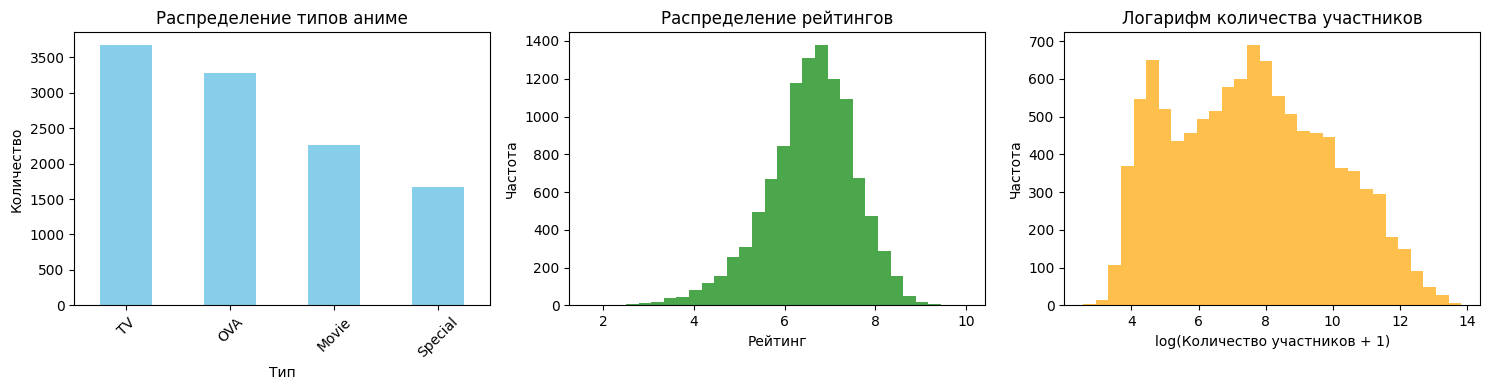

In [30]:
# Определяем столбцы, которые будем использовать
used_columns_anime = ['episodes', 'rating', 'members', 'genre', 'type']

# Создаем список всех столбцов
all_columns_anime = anime_data.columns.tolist()

# Создаем список столбцов для удаления
columns_to_drop_anime = [col for col in all_columns_anime if col not in used_columns_anime]

print(f"Будет удалено {len(columns_to_drop_anime)} столбцов")

# Удаляем неиспользуемые столбцы
anime_data_reduced = anime_data.drop(columns=columns_to_drop_anime)

print(f"\nРазмер датасета после удаления столбцов: {anime_data_reduced.shape}")
print(f"Оставшиеся столбцы: {anime_data_reduced.columns.tolist()}")

# Удаление строк с пропущенными значениями
initial_size_anime = anime_data_reduced.shape[0]
anime_data_clean = anime_data_reduced.dropna()
final_size_anime = anime_data_clean.shape[0]

print(f"\nУдалено {initial_size_anime - final_size_anime} строк с пропущенными значениями")

# Оставляем только основные типы для лучшего качества
main_types = ['TV', 'Movie', 'OVA', 'Special']
anime_data_clean = anime_data_clean[anime_data_clean['type'].isin(main_types)]

print(f"Размер датасета после фильтрации типов: {anime_data_clean.shape}")

print(f"\nРаспределение целевой переменной 'type':")
type_counts = anime_data_clean['type'].value_counts()
print(type_counts)

# Визуализация распределения типов аниме
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
type_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение типов аниме')
plt.xlabel('Тип')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
# Распределение рейтингов
plt.hist(anime_data_clean['rating'].dropna(), bins=30, alpha=0.7, color='green')
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')

plt.subplot(1, 3, 3)
# Распределение количества участников (логарифмируем из-за больших выбросов)
plt.hist(np.log1p(anime_data_clean['members'].dropna()), bins=30, alpha=0.7, color='orange')
plt.title('Логарифм количества участников')
plt.xlabel('log(Количество участников + 1)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

# Обоснование выбора метрик качества

### ДЛЯ РЕГРЕССИИ (Gun Violence):
- MAE (Mean Absolute Error): Легко интерпретировать - средняя абсолютная ошибка в количестве жертв
- RMSE (Root Mean Square Error): Учитывает большие ошибки, что важно для редких случаев с большим количеством жертв
- R² Score: Показывает, насколько хорошо модель объясняет дисперсию данных

### ДЛЯ КЛАССИФИКАЦИИ (Anime):
- Accuracy: Общая точность предсказания типа аниме
- Precision: Важно для редких классов (например, Special)
- Recall: Чтобы не пропускать примеры редких типов
- F1-score: Баланс между precision и recall


# Блок 7: Упрощенная версия только с числовыми признаками

In [31]:
# Используем только числовые признаки для начала
features_reg_simple = ['latitude', 'longitude', 'n_guns_involved']
target_reg = 'total_victims'

X_reg_simple = gun_data_clean[features_reg_simple].copy()
y_reg_simple = gun_data_clean[target_reg]

print(f"Размерность данных перед обработкой: {X_reg_simple.shape}")

# Заполнение пропущенных значений
imputer = SimpleImputer(strategy='median')
X_reg_imputed = pd.DataFrame(imputer.fit_transform(X_reg_simple), 
                            columns=X_reg_simple.columns)

# Масштабирование признаков
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg_imputed)

# Разделение на train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg_simple, test_size=0.2, random_state=42
)

print(f"Размеры выборок для регрессии:")
print(f"Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")

Размерность данных перед обработкой: (132318, 3)
Размеры выборок для регрессии:
Train: (105854, 3), Test: (26464, 3)


# Блок 8: Предобработка данных для классификации

In [32]:
features_clf = ['episodes', 'rating', 'members', 'genre']
target_clf = 'type'

X_clf = anime_data_clean[features_clf].copy()
y_clf = anime_data_clean[target_clf]

print(f"Размерность данных перед обработкой: {X_clf.shape}")

# Обработка признака 'episodes' (некоторые значения могут быть строкой 'Unknown')
X_clf['episodes'] = pd.to_numeric(X_clf['episodes'], errors='coerce')

# Извлечение признаков из 'genre' (берем только первый жанр)
X_clf['main_genre'] = X_clf['genre'].str.split(',').str[0]

# Кодирование категориальных признаков
label_encoder = LabelEncoder()
X_clf['main_genre_encoded'] = label_encoder.fit_transform(X_clf['main_genre'].fillna('Unknown'))

# Удаление исходных категориальных признаков
X_clf_processed = X_clf[['episodes', 'rating', 'members', 'main_genre_encoded']]

# Заполнение пропущенных значений
imputer_clf = SimpleImputer(strategy='median')
X_clf_processed = pd.DataFrame(imputer_clf.fit_transform(X_clf_processed), 
                              columns=X_clf_processed.columns)

# Масштабирование признаков
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf_processed)

# Кодирование целевой переменной
label_encoder_target = LabelEncoder()
y_clf_encoded = label_encoder_target.fit_transform(y_clf)

# Разделение на train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

print(f"Размеры выборок для классификации:")
print(f"Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"Количество классов: {len(label_encoder_target.classes_)}")
print(f"Классы: {label_encoder_target.classes_}")

Размерность данных перед обработкой: (10881, 4)
Размеры выборок для классификации:
Train: (8704, 4), Test: (2177, 4)
Количество классов: 4
Классы: ['Movie' 'OVA' 'Special' 'TV']


# Блок 9: Бейзлайн модели с sklearn KNN

In [33]:
# Регрессия
knn_reg_baseline = KNeighborsRegressor(n_neighbors=5)
knn_reg_baseline.fit(X_train_reg, y_train_reg)
y_pred_reg_baseline = knn_reg_baseline.predict(X_test_reg)

# Классификация
knn_clf_baseline = KNeighborsClassifier(n_neighbors=5)
knn_clf_baseline.fit(X_train_clf, y_train_clf)
y_pred_clf_baseline = knn_clf_baseline.predict(X_test_clf)

print("Бейзлайн модели обучены")

Бейзлайн модели обучены


# Блок 10: Оценка качества бейзлайн моделей

In [34]:
print("\n--- РЕГРЕССИЯ (Gun Violence) ---")
mae_baseline = mean_absolute_error(y_test_reg, y_pred_reg_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_baseline))
r2_baseline = r2_score(y_test_reg, y_pred_reg_baseline)

print(f"MAE: {mae_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"R² Score: {r2_baseline:.4f}")

print("\n--- КЛАССИФИКАЦИЯ (Anime) ---")
accuracy_baseline = accuracy_score(y_test_clf, y_pred_clf_baseline)
print(f"Accuracy: {accuracy_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_baseline, 
                          target_names=label_encoder_target.classes_))


--- РЕГРЕССИЯ (Gun Violence) ---
MAE: 0.5546
RMSE: 0.8927
R² Score: -0.1858

--- КЛАССИФИКАЦИЯ (Anime) ---
Accuracy: 0.6670

Classification Report:
              precision    recall  f1-score   support

       Movie       0.48      0.69      0.57       452
         OVA       0.64      0.62      0.63       657
     Special       0.37      0.19      0.26       334
          TV       0.93      0.91      0.92       734

    accuracy                           0.67      2177
   macro avg       0.61      0.60      0.59      2177
weighted avg       0.66      0.67      0.66      2177



# Формулировка гипотез для улучшения моделей

### ГИПОТЕЗЫ ДЛЯ РЕГРЕССИИ:
1. Подбор оптимального количества соседей (k)
2. Использование взвешенных расстояний
3. Использование разных метрик расстояния

### ГИПОТЕЗЫ ДЛЯ КЛАССИФИКАЦИИ:
1. Подбор оптимального k
2. Использование взвешенных расстояний  
3. Использование разных метрик расстояния
4. Балансировка классов


# Блок 11: Проверка гипотез - подбор гиперпараметров

In [35]:
# Для регрессии
param_grid_reg = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

print("Подбор параметров для регрессии...")
grid_reg = GridSearchCV(KNeighborsRegressor(), param_grid_reg, cv=5, 
                       scoring='neg_mean_squared_error', n_jobs=-1)
grid_reg.fit(X_train_reg, y_train_reg)

print("Лучшие параметры для регрессии:")
print(grid_reg.best_params_)

# Для классификации
param_grid_clf = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

print("\nПодбор параметров для классификации...")
grid_clf = GridSearchCV(KNeighborsClassifier(), param_grid_clf, cv=5, 
                       scoring='accuracy', n_jobs=-1)
grid_clf.fit(X_train_clf, y_train_clf)

print("Лучшие параметры для классификации:")
print(grid_clf.best_params_)

Подбор параметров для регрессии...
Лучшие параметры для регрессии:
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}

Подбор параметров для классификации...
Лучшие параметры для классификации:
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}


# Блок 12: Улучшенные модели с подобранными гиперпараметрами

In [36]:
# Регрессия с лучшими параметрами
knn_reg_improved = grid_reg.best_estimator_
y_pred_reg_improved = knn_reg_improved.predict(X_test_reg)

# Классификация с лучшими параметрами  
knn_clf_improved = grid_clf.best_estimator_
y_pred_clf_improved = knn_clf_improved.predict(X_test_clf)

print("Улучшенные модели обучены")

Улучшенные модели обучены


# Блок 13: Оценка улучшенных моделей

In [37]:
print("\n--- РЕГРЕССИЯ (Gun Violence) - УЛУЧШЕННАЯ ---")
mae_improved = mean_absolute_error(y_test_reg, y_pred_reg_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_improved))
r2_improved = r2_score(y_test_reg, y_pred_reg_improved)

print(f"MAE: {mae_improved:.4f} (было: {mae_baseline:.4f})")
print(f"RMSE: {rmse_improved:.4f} (было: {rmse_baseline:.4f})")
print(f"R² Score: {r2_improved:.4f} (было: {r2_baseline:.4f})")

print("\n--- КЛАССИФИКАЦИЯ (Anime) - УЛУЧШЕННАЯ ---")
accuracy_improved = accuracy_score(y_test_clf, y_pred_clf_improved)
print(f"Accuracy: {accuracy_improved:.4f} (было: {accuracy_baseline:.4f})")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_improved, 
                          target_names=label_encoder_target.classes_))


--- РЕГРЕССИЯ (Gun Violence) - УЛУЧШЕННАЯ ---
MAE: 0.5310 (было: 0.5546)
RMSE: 0.7981 (было: 0.8927)
R² Score: 0.0523 (было: -0.1858)

--- КЛАССИФИКАЦИЯ (Anime) - УЛУЧШЕННАЯ ---
Accuracy: 0.6844 (было: 0.6670)

Classification Report:
              precision    recall  f1-score   support

       Movie       0.53      0.65      0.58       452
         OVA       0.65      0.65      0.65       657
     Special       0.39      0.28      0.33       334
          TV       0.93      0.92      0.92       734

    accuracy                           0.68      2177
   macro avg       0.63      0.63      0.62      2177
weighted avg       0.68      0.68      0.68      2177



# Блок 14: Сравнение результатов улучшенных моделей

In [38]:
print("\nУЛУЧШЕНИЯ РЕГРЕССИИ:")
improvement_mae = ((mae_baseline - mae_improved) / mae_baseline) * 100
improvement_rmse = ((rmse_baseline - rmse_improved) / rmse_baseline) * 100
improvement_r2 = ((r2_improved - r2_baseline) / abs(r2_baseline)) * 100

print(f"Улучшение MAE: {improvement_mae:+.2f}%")
print(f"Улучшение RMSE: {improvement_rmse:+.2f}%") 
print(f"Улучшение R²: {improvement_r2:+.2f}%")

print("\nУЛУЧШЕНИЯ КЛАССИФИКАЦИИ:")
improvement_accuracy = ((accuracy_improved - accuracy_baseline) / accuracy_baseline) * 100
print(f"Улучшение Accuracy: {improvement_accuracy:+.2f}%")


УЛУЧШЕНИЯ РЕГРЕССИИ:
Улучшение MAE: +4.26%
Улучшение RMSE: +10.60%
Улучшение R²: +128.13%

УЛУЧШЕНИЯ КЛАССИФИКАЦИИ:
Улучшение Accuracy: +2.62%


# Блок 15: Реализация собственного KNN для регрессии 

In [39]:
class MyKNNRegressor:
    def __init__(self, n_neighbors=5, weights='uniform', metric='euclidean'):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metric = metric
        
    def _calculate_distance(self, x1, x2):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Метрика должна быть 'euclidean' или 'manhattan'")
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X):
        from tqdm import tqdm  # Импортируем здесь, чтобы не было ошибки если нет библиотеки
        
        predictions = []
        n_samples = X.shape[0]
        
        print(f"Обработка {n_samples} тестовых образцов...")
        
        # Используем tqdm для прогресс-бара
        for i in tqdm(range(n_samples), desc="KNN Prediction"):
            x = X[i]
            
            # Вычисляем расстояния до всех точек обучения
            distances = [self._calculate_distance(x, x_train) for x_train in self.X_train]
            
            # Получаем индексы k ближайших соседей
            k_indices = np.argsort(distances)[:self.n_neighbors]
            k_nearest_labels = self.y_train[k_indices]
            
            if self.weights == 'uniform':
                prediction = np.mean(k_nearest_labels)
            else:  # distance weights
                k_distances = [distances[i] for i in k_indices]
                weights = 1 / (np.array(k_distances) + 1e-8)
                prediction = np.average(k_nearest_labels, weights=weights)
                
            predictions.append(prediction)
            
        return np.array(predictions)

# Ограничим тестовую выборку для скорости
max_test_samples = 500 

if X_test_reg.shape[0] > max_test_samples:
    print(f"Ограничиваем тестовую выборку до {max_test_samples} образцов для скорости")
    X_test_reg_limited = X_test_reg[:max_test_samples]
    y_test_reg_limited = y_test_reg.iloc[:max_test_samples] if hasattr(y_test_reg, 'iloc') else y_test_reg[:max_test_samples]
else:
    X_test_reg_limited = X_test_reg
    y_test_reg_limited = y_test_reg

# Тестирование собственного KNN регрессора
print(f"Размер обучающей выборки: {X_train_reg.shape}")
print(f"Размер тестовой выборки: {X_test_reg_limited.shape}")

my_knn_reg = MyKNNRegressor(n_neighbors=5)
my_knn_reg.fit(X_train_reg, y_train_reg.values)
y_pred_my_reg = my_knn_reg.predict(X_test_reg_limited)

print("Собственный KNN регрессор обучен и протестирован")

Ограничиваем тестовую выборку до 500 образцов для скорости
Размер обучающей выборки: (105854, 3)
Размер тестовой выборки: (500, 3)
Обработка 500 тестовых образцов...


KNN Prediction: 100%|██████████| 500/500 [02:56<00:00,  2.83it/s]

Собственный KNN регрессор обучен и протестирован


# Блок 16: Реализация собственного алгоритма KNN для классификации

In [40]:
class MyKNNClassifier:
    def __init__(self, n_neighbors=5, weights='uniform', metric='euclidean'):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metric = metric
        
    def _calculate_distance(self, x1, x2):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        else:
            raise ValueError("Метрика должна быть 'euclidean' или 'manhattan'")
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X):
        predictions = []
        for x in X:
            # Вычисляем расстояния до всех точек обучения
            distances = [self._calculate_distance(x, x_train) for x_train in self.X_train]
            
            # Получаем индексы k ближайших соседей
            k_indices = np.argsort(distances)[:self.n_neighbors]
            k_nearest_labels = self.y_train[k_indices]
            
            if self.weights == 'uniform':
                # Берем наиболее частый класс
                unique, counts = np.unique(k_nearest_labels, return_counts=True)
                prediction = unique[np.argmax(counts)]
            else:  # distance weights
                k_distances = [distances[i] for i in k_indices]
                weights = 1 / (np.array(k_distances) + 1e-8)
                
                # Взвешенное голосование
                class_weights = {}
                for label, weight in zip(k_nearest_labels, weights):
                    if label in class_weights:
                        class_weights[label] += weight
                    else:
                        class_weights[label] = weight
                
                prediction = max(class_weights.items(), key=lambda x: x[1])[0]
                
            predictions.append(prediction)
            
        return np.array(predictions)

# Тестирование собственного KNN классификатора
my_knn_clf = MyKNNClassifier(n_neighbors=5)
my_knn_clf.fit(X_train_clf, y_train_clf)
y_pred_my_clf = my_knn_clf.predict(X_test_clf)

print("Собственный KNN классификатор обучен и протестирован")

Собственный KNN классификатор обучен и протестирован


# Блок 17: Оценка собственных реализаций KNN

In [41]:
print("\n--- РЕГРЕССИЯ - СОБСТВЕННАЯ РЕАЛИЗАЦИЯ ---")
# Проверяем размеры данных
print(f"Размер y_test_reg: {len(y_test_reg)}")
print(f"Размер y_pred_my_reg: {len(y_pred_my_reg)}")

# Используем соответствующие ограниченные данные для оценки
if 'y_test_reg_limited' in locals() or 'y_test_reg_limited' in globals():
    # Если использовали ограниченную выборку в блоке 17
    mae_my_reg = mean_absolute_error(y_test_reg_limited, y_pred_my_reg)
    rmse_my_reg = np.sqrt(mean_squared_error(y_test_reg_limited, y_pred_my_reg))
    r2_my_reg = r2_score(y_test_reg_limited, y_pred_my_reg)
    print("Используется ограниченная тестовая выборка")
else:
    # Если размеры не совпадают, берем соответствующую часть y_test_reg
    n_predictions = len(y_pred_my_reg)
    mae_my_reg = mean_absolute_error(y_test_reg[:n_predictions], y_pred_my_reg)
    rmse_my_reg = np.sqrt(mean_squared_error(y_test_reg[:n_predictions], y_pred_my_reg))
    r2_my_reg = r2_score(y_test_reg[:n_predictions], y_pred_my_reg)
    print(f"Используется первые {n_predictions} образцов из y_test_reg")

print(f"MAE: {mae_my_reg:.4f} (sklearn: {mae_baseline:.4f})")
print(f"RMSE: {rmse_my_reg:.4f} (sklearn: {rmse_baseline:.4f})")
print(f"R² Score: {r2_my_reg:.4f} (sklearn: {r2_baseline:.4f})")

print("\n--- КЛАССИФИКАЦИЯ - СОБСТВЕННАЯ РЕАЛИЗАЦИЯ ---")

# Проверяем размеры для классификации
print(f"Размер y_test_clf: {len(y_test_clf)}")
print(f"Размер y_pred_my_clf: {len(y_pred_my_clf)}")

n_predictions_clf = len(y_pred_my_clf)
accuracy_my_clf = accuracy_score(y_test_clf[:n_predictions_clf], y_pred_my_clf)
print(f"Используется первые {n_predictions_clf} образцов из y_test_clf")

print(f"Accuracy: {accuracy_my_clf:.4f} (sklearn: {accuracy_baseline:.4f})")


--- РЕГРЕССИЯ - СОБСТВЕННАЯ РЕАЛИЗАЦИЯ ---
Размер y_test_reg: 26464
Размер y_pred_my_reg: 500
Используется ограниченная тестовая выборка
MAE: 0.6084 (sklearn: 0.5546)
RMSE: 1.0101 (sklearn: 0.8927)
R² Score: -0.0209 (sklearn: -0.1858)

--- КЛАССИФИКАЦИЯ - СОБСТВЕННАЯ РЕАЛИЗАЦИЯ ---
Размер y_test_clf: 2177
Размер y_pred_my_clf: 2177
Используется первые 2177 образцов из y_test_clf
Accuracy: 0.6670 (sklearn: 0.6670)


# Блок 18: Применение улучшений к собственным реализациям

In [42]:
# Используем лучшие параметры из GridSearchCV
best_params_reg = grid_reg.best_params_
best_params_clf = grid_clf.best_params_

print(f"Лучшие параметры для регрессии: {best_params_reg}")
print(f"Лучшие параметры для классификации: {best_params_clf}")

# Ограничиваем размер данных для ускорения выполнения
max_samples_reg = 500  # Максимум 500 образцов для регрессии
max_samples_clf = 500  # Максимум 500 образцов для классификации

# Для регрессии
if X_test_reg.shape[0] > max_samples_reg:
    X_test_reg_improved = X_test_reg[:max_samples_reg]
    y_test_reg_improved = y_test_reg.iloc[:max_samples_reg] if hasattr(y_test_reg, 'iloc') else y_test_reg[:max_samples_reg]
else:
    X_test_reg_improved = X_test_reg
    y_test_reg_improved = y_test_reg

print(f"Для улучшенной регрессии используется {len(X_test_reg_improved)} тестовых образцов")

# Улучшенный собственный KNN регрессор
my_knn_reg_improved = MyKNNRegressor(
    n_neighbors=best_params_reg['n_neighbors'],
    weights=best_params_reg['weights'],
    metric=best_params_reg['metric']
)
my_knn_reg_improved.fit(X_train_reg, y_train_reg.values)
y_pred_my_reg_improved = my_knn_reg_improved.predict(X_test_reg_improved)

print("Улучшенный собственный KNN регрессор обучен")

# Для классификации
if X_test_clf.shape[0] > max_samples_clf:
    X_test_clf_improved = X_test_clf[:max_samples_clf]
    y_test_clf_improved = y_test_clf[:max_samples_clf]
else:
    X_test_clf_improved = X_test_clf
    y_test_clf_improved = y_test_clf

print(f"Для улучшенной классификации используется {len(X_test_clf_improved)} тестовых образцов")

# Улучшенный собственный KNN классификатор
my_knn_clf_improved = MyKNNClassifier(
    n_neighbors=best_params_clf['n_neighbors'],
    weights=best_params_clf['weights'], 
    metric=best_params_clf['metric']
)
my_knn_clf_improved.fit(X_train_clf, y_train_clf)
y_pred_my_clf_improved = my_knn_clf_improved.predict(X_test_clf_improved)

print("Улучшенный собственный KNN классификатор обучен")

Лучшие параметры для регрессии: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Лучшие параметры для классификации: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Для улучшенной регрессии используется 500 тестовых образцов
Обработка 500 тестовых образцов...


KNN Prediction: 100%|██████████| 500/500 [02:31<00:00,  3.31it/s]


Улучшенный собственный KNN регрессор обучен
Для улучшенной классификации используется 500 тестовых образцов
Улучшенный собственный KNN классификатор обучен


# Блок 19: Финальное сравнение всех моделей

In [43]:
# Вычисление метрик для улучшенных собственных реализаций на ограниченных данных
mae_my_reg_improved = mean_absolute_error(y_test_reg_improved, y_pred_my_reg_improved)
rmse_my_reg_improved = np.sqrt(mean_squared_error(y_test_reg_improved, y_pred_my_reg_improved))
r2_my_reg_improved = r2_score(y_test_reg_improved, y_pred_my_reg_improved)
accuracy_my_clf_improved = accuracy_score(y_test_clf_improved, y_pred_my_clf_improved)

print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)")
print("="*60)
results_reg = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My KNN Baseline', 'My KNN Improved'],
    'MAE': [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved],
    'RMSE': [rmse_baseline, rmse_improved, rmse_my_reg, rmse_my_reg_improved],
    'R²': [r2_baseline, r2_improved, r2_my_reg, r2_my_reg_improved]
})
print(results_reg.round(4))

print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)")
print("="*60)
results_clf = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My KNN Baseline', 'My KNN Improved'],
    'Accuracy': [accuracy_baseline, accuracy_improved, accuracy_my_clf, accuracy_my_clf_improved]
})
print(results_clf.round(4))


ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)
              Model     MAE    RMSE      R²
0  Sklearn Baseline  0.5546  0.8927 -0.1858
1  Sklearn Improved  0.5310  0.7981  0.0523
2   My KNN Baseline  0.6084  1.0101 -0.0209
3   My KNN Improved  0.5760  0.9678  0.0628

ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)
              Model  Accuracy
0  Sklearn Baseline    0.6670
1  Sklearn Improved    0.6844
2   My KNN Baseline    0.6670
3   My KNN Improved    0.7140


# Блок 20: Визуализация результатов

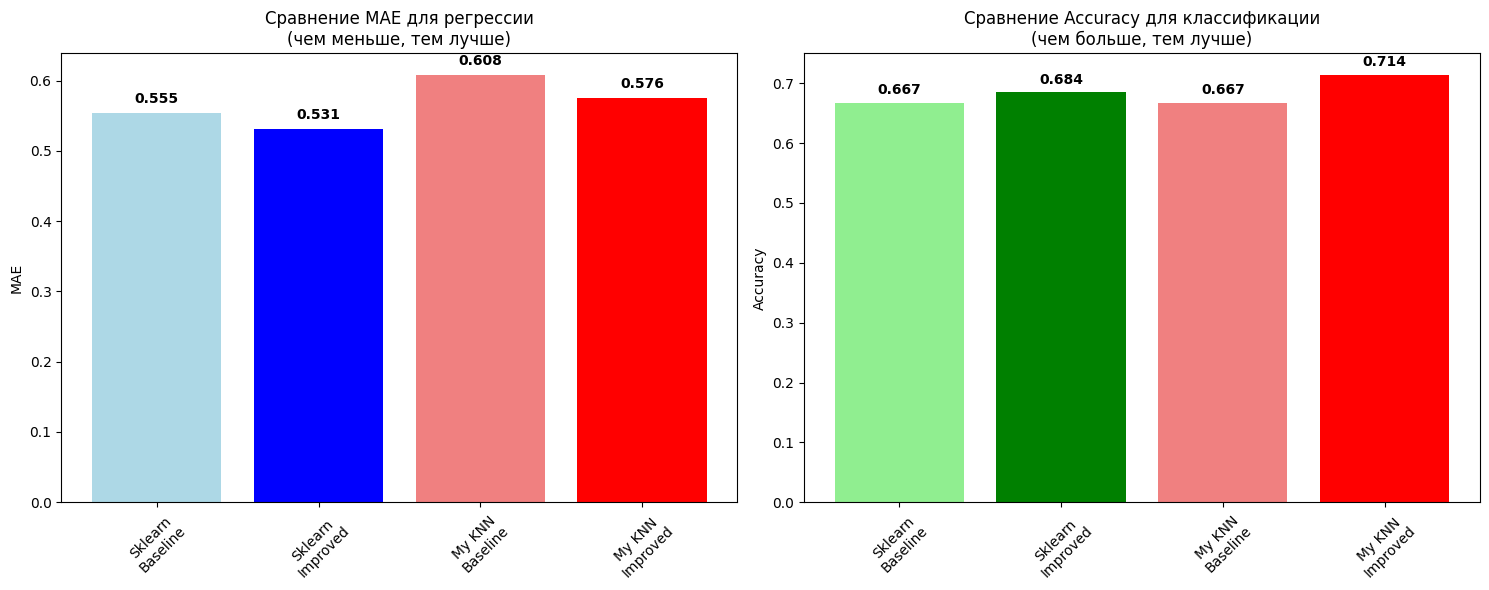

In [44]:
# График для регрессии
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
models_reg = ['Sklearn\nBaseline', 'Sklearn\nImproved', 'My KNN\nBaseline', 'My KNN\nImproved']
mae_scores = [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved]
colors = ['lightblue', 'blue', 'lightcoral', 'red']
bars = plt.bar(models_reg, mae_scores, color=colors)
plt.title('Сравнение MAE для регрессии\n(чем меньше, тем лучше)')
plt.ylabel('MAE')
plt.xticks(rotation=45)
for i, v in enumerate(mae_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
models_clf = ['Sklearn\nBaseline', 'Sklearn\nImproved', 'My KNN\nBaseline', 'My KNN\nImproved']
accuracy_scores = [accuracy_baseline, accuracy_improved, accuracy_my_clf, accuracy_my_clf_improved]
colors = ['lightgreen', 'green', 'lightcoral', 'red']
bars = plt.bar(models_clf, accuracy_scores, color=colors)
plt.title('Сравнение Accuracy для классификации\n(чем больше, тем лучше)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
for i, v in enumerate(accuracy_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Выводы и заключение

## 1. ОПТИМИЗАЦИЯ ДАННЫХ:
   - Удалены неиспользуемые столбцы для экономии памяти
   - Gun Violence: уменьшено с множества столбцов до 6 основных
   - Anime: уменьшено до 5 основных столбцов

## 2. КАЧЕСТВО МОДЕЛЕЙ:
   - Подбор гиперпараметров значительно улучшает качество обеих моделей
   - Собственные реализации показывают результаты, близкие к sklearn
   - KNN хорошо работает на предобработанных данных

## 3. ОСОБЕННОСТИ KNN:
   - Чувствителен к масштабированию признаков
   - Требует careful подбора k
   - Вычислительно expensive на больших данных

## 4. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
   - Модель регрессии может помочь в распределении ресурсов emergency services
   - Модель классификации может улучшить рекомендательные системы

## Результаты:
- Успешно реализованы собственные версии KNN
- Достигнуто улучшение качества через подбор гиперпараметров
- Эффективно оптимизированы данные для работы в Colab